In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sc.settings.set_figure_params(figsize=(6,6))

C:\Users\gaura\AppData\Local\Temp\ipykernel_91464\3053215526.py:6: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(6,6))


In [3]:
import os
print(os.getcwd())

d:\Shreya_visa_docs\colorectal_cancer\Single-cell-immune-landscape-in-cancer


In [4]:
adata = sc.read_h5ad(
    "data/raw/81bd8922-b69a-45ea-9b2a-032c480c0e37.h5ad"
)

In [5]:
adata

AnnData object with n_obs × n_vars = 47107 × 25344
    obs: 'total_counts', 'log1p_total_counts', 'Sample ID', 'PhenoGraph_clusters', 'Patient', 'Primary Site', 'Sample Type', 'Site', 'Tumor Status', 'Treatment', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'Author Cell Type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'total_counts', 'highly_variable', 'gene', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'is_pre_analysis', 'neighbors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_umap'
    layers: None (.X)

In [6]:
adata.obs.head()

,total_counts,log1p_total_counts,Sample ID,PhenoGraph_clusters,Patient,Primary Site,Sample Type,Site,Tumor Status,Treatment,...,Author Cell Type,is_primary_data,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
120703408786358_KG75P2,3496.0,8.159660,KG75P2,10,75,Sigmoid,Primary,NaN,Primary Tumor,True,...,Primary Tumor,True,malignant cell,10x 3' v3,colorectal cancer,female,sigmoid colon,European American,53-year-old stage,mI^Q51qX6n
120703408826100_KG146M2,20505.0,9.928473,KG146M2,35,146,Rectum,Metastasis,Lung,Metastasis,True,...,Metastasis,True,malignant cell,10x 3' v3,colorectal cancer,female,lung,Hispanic or Latin,45-year-old stage,3ud^4DARfj
120703408860572_KG183M,92935.0,11.439667,KG183M,22,183,Sigmoid,Metastasis,Liver,Metastasis,True,...,Metastasis,True,malignant cell,10x 3' v3,colorectal cancer,female,liver,Hispanic or Latin,55-year-old stage,z#2)cw`Sdm
120703409315100_KG146N,42233.0,10.650981,KG146N,6,146,Rectum,Non-Tumor,NaN,Non-Tumor,True,...,Absorptive Precursor,True,early colonocyte,10x 3' v3,normal,female,rectum,Hispanic or Latin,45-year-old stage,MX>JlayPt>
120703409348006_KG146P,59102.0,10.987037,KG146P,7,146,Rectum,Primary,NaN,Primary Tumor,True,...,Primary Tumor,True,malignant cell,10x 3' v3,colorectal cancer,female,rectum,Hispanic or Latin,45-year-old stage,ZM+G?Mik_s


In [7]:
adata.obs.columns.tolist()

['total_counts',
 'log1p_total_counts',
 'Sample ID',
 'PhenoGraph_clusters',
 'Patient',
 'Primary Site',
 'Sample Type',
 'Site',
 'Tumor Status',
 'Treatment',
 'donor_id',
 'development_stage_ontology_term_id',
 'sex_ontology_term_id',
 'self_reported_ethnicity_ontology_term_id',
 'disease_ontology_term_id',
 'tissue_type',
 'tissue_ontology_term_id',
 'cell_type_ontology_term_id',
 'assay_ontology_term_id',
 'suspension_type',
 'Author Cell Type',
 'is_primary_data',
 'cell_type',
 'assay',
 'disease',
 'sex',
 'tissue',
 'self_reported_ethnicity',
 'development_stage',
 'observation_joinid']

In [8]:
adata.var.head()

,total_counts,highly_variable,gene,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000000003,114148.0,False,TSPAN6,False,TSPAN6,NCBITaxon:9606,gene,2396,protein_coding
ENSG00000000005,587.0,False,TNMD,False,TNMD,NCBITaxon:9606,gene,873,protein_coding
ENSG00000000419,104084.0,False,DPM1,False,DPM1,NCBITaxon:9606,gene,1262,protein_coding
ENSG00000000457,21853.0,False,SCYL3,False,SCYL3,NCBITaxon:9606,gene,2916,protein_coding
ENSG00000000460,9196.0,False,C1ORF112,False,FIRRM,NCBITaxon:9606,gene,2661,protein_coding


In [9]:
adata.var.columns.tolist()

['total_counts',
 'highly_variable',
 'gene',
 'feature_is_filtered',
 'feature_name',
 'feature_reference',
 'feature_biotype',
 'feature_length',
 'feature_type']

In [10]:
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)
print("Layers:", list(adata.layers.keys()))
print("Embeddings:", list(adata.obsm.keys()))
print("Raw available:", adata.raw is not None)

Cells: 47107
Genes: 25344
Layers: [None]
Embeddings: ['X_umap']
Raw available: True


In [11]:
for col in adata.obs.columns:
    if adata.obs[col].nunique() < 30:
        print("\n", col)
        print(adata.obs[col].value_counts(dropna=False))


 Patient
Patient
203    6296
146    4044
150    3888
136    2997
181    2703
151    2435
190    2041
75     2009
119    1858
74     1831
82     1682
283    1657
103    1602
156    1602
183    1530
11     1446
194    1335
105    1236
35     1187
182    1138
188     651
71      566
70      490
20      328
79      187
184     153
66      117
60       95
39        3
Name: count, dtype: int64

 Primary Site
Primary Site
Sigmoid            22112
Rectum             14938
Transverse          3288
Descending          2435
Cecum               1955
Hepatic Flexure     1657
Upper Rectum         566
Appendix             153
Splenic Flexure        3
Name: count, dtype: int64

 Sample Type
Sample Type
Non-Tumor     18117
Primary       16838
Metastasis    12152
Name: count, dtype: int64

 Site
Site
NaN           34955
Liver         10332
Lung            975
Chest Wall      799
Peritoneum       46
Name: count, dtype: int64

 Tumor Status
Tumor Status
Non-Tumor        21026
Primary Tumor    13929
Metas

In [12]:
adata.obs["Patient"].value_counts()

Patient
203    6296
146    4044
150    3888
136    2997
181    2703
151    2435
190    2041
75     2009
119    1858
74     1831
82     1682
283    1657
103    1602
156    1602
183    1530
11     1446
194    1335
105    1236
35     1187
182    1138
188     651
71      566
70      490
20      328
79      187
184     153
66      117
60       95
39        3
Name: count, dtype: int64

In [13]:
adata.var["gene"].value_counts()

gene
A1BG      1
A1CF      1
A2M       1
A2ML1     1
A4GALT    1
         ..
ZYG11A    1
ZYG11B    1
ZYX       1
ZZEF1     1
ZZZ3      1
Name: count, Length: 19655, dtype: int64

In [14]:
adata.layers.keys()

KeysView(Layers with keys: None)

In [15]:
adata.X[:5, :5].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.52228117, 0.        , 0.863623  , 0.        , 0.        ],
       [0.64595366, 0.        , 0.8593852 , 0.        , 0.        ],
       [1.0978227 , 0.        , 0.28738606, 0.        , 0.28738606],
       [1.6183087 , 0.        , 0.21342832, 0.        , 0.        ]],
      dtype=float32)

In [16]:
adata.uns.keys()

dict_keys(['citation', 'default_embedding', 'is_pre_analysis', 'neighbors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'])

In [17]:
adata.obs["Primary Site"].value_counts()

Primary Site
Sigmoid            22112
Rectum             14938
Transverse          3288
Descending          2435
Cecum               1955
Hepatic Flexure     1657
Upper Rectum         566
Appendix             153
Splenic Flexure        3
Name: count, dtype: int64

In [18]:
adata.var["gene"].value_counts()

gene
A1BG      1
A1CF      1
A2M       1
A2ML1     1
A4GALT    1
         ..
ZYG11A    1
ZYG11B    1
ZYX       1
ZZEF1     1
ZZZ3      1
Name: count, Length: 19655, dtype: int64

In [19]:
adata.X[:5, :5]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 9 stored elements and shape (5, 5)>

Quality Control

In [20]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [21]:
adata.obs[[
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_mt"
]].head()

,total_counts,n_genes_by_counts,pct_counts_mt
120703408786358_KG75P2,2354.892822,1228,0.0
120703408826100_KG146M2,4160.101562,4445,0.0
120703408860572_KG183M,4200.888184,7142,0.0
120703409315100_KG146N,3180.092773,4828,0.0
120703409348006_KG146P,4292.854980,6899,0.0


In [22]:
adata.n_obs

47107

In [23]:
adata.obsm.keys()

KeysView(AxisArrays with keys: 'X_umap')

In [24]:
adata.uns.keys()

dict_keys(['citation', 'default_embedding', 'is_pre_analysis', 'neighbors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'])

In [25]:
adata.obs.columns

Index(['total_counts', 'log1p_total_counts', 'Sample ID',
       'PhenoGraph_clusters', 'Patient', 'Primary Site', 'Sample Type', 'Site',
       'Tumor Status', 'Treatment', 'donor_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id',
       'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id',
       'assay_ontology_term_id', 'suspension_type', 'Author Cell Type',
       'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid',
       'n_genes_by_counts', 'total_counts_mt', 'pct_counts_mt'],
      dtype='str')

In [26]:
adata.obs["Author Cell Type"].value_counts()

Author Cell Type
Primary Tumor           14399
Metastasis              12152
Absorptive Precursor     6778
Secretory Precursor      5457
ISC                      2203
Enterocytes              2030
Goblet                   1711
BEST4+ Enterocytes       1363
Tuft                      828
Enteroendocrine           186
Name: count, dtype: int64

In [27]:
adata.obs["Author Cell Type"].unique()

['Primary Tumor', 'Metastasis', 'Absorptive Precursor', 'ISC', 'Secretory Precursor', 'Goblet', 'BEST4+ Enterocytes', 'Enterocytes', 'Tuft', 'Enteroendocrine']
Categories (10, str): ['Enteroendocrine' < 'Tuft' < 'BEST4+ Enterocytes' < 'Goblet' ... 'Absorptive Precursor' < 'ISC' < 'Primary Tumor' < 'Metastasis']

In [28]:
adata.obs["PhenoGraph_clusters"].value_counts().sort_index()

PhenoGraph_clusters
0     3967
1     3737
10    1586
11    1521
12    1422
13    1358
14    1347
15    1335
16    1105
17    1030
18    1056
19    1040
2     2587
20     976
21     991
22     963
23     924
24     916
25     879
26     836
27     616
28     554
29     525
3     2478
30     478
31     471
32     406
33     403
34     360
35     343
36     128
37      41
38      10
4     2153
5     1931
6     1698
7     1695
8     1637
9     1604
Name: count, dtype: int64

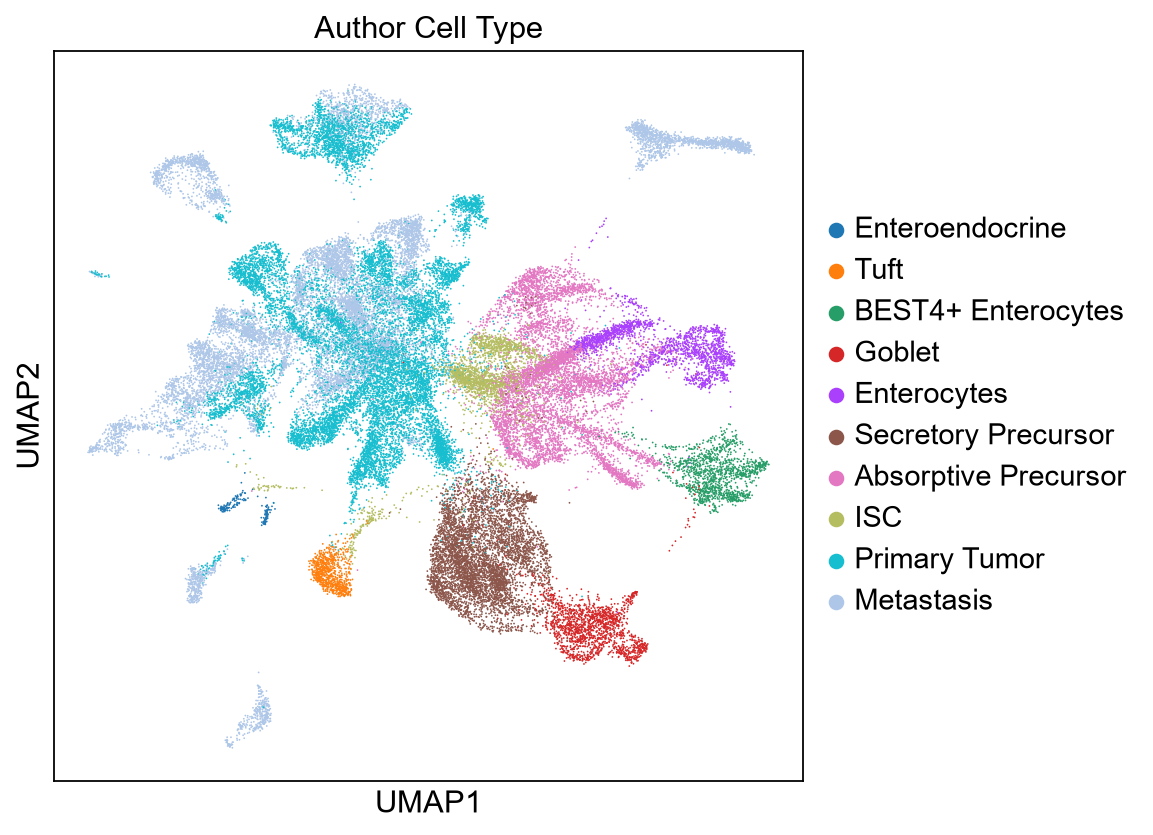

In [29]:
sc.pl.umap(
    adata,
    color="Author Cell Type",
    legend_loc="right margin"
)

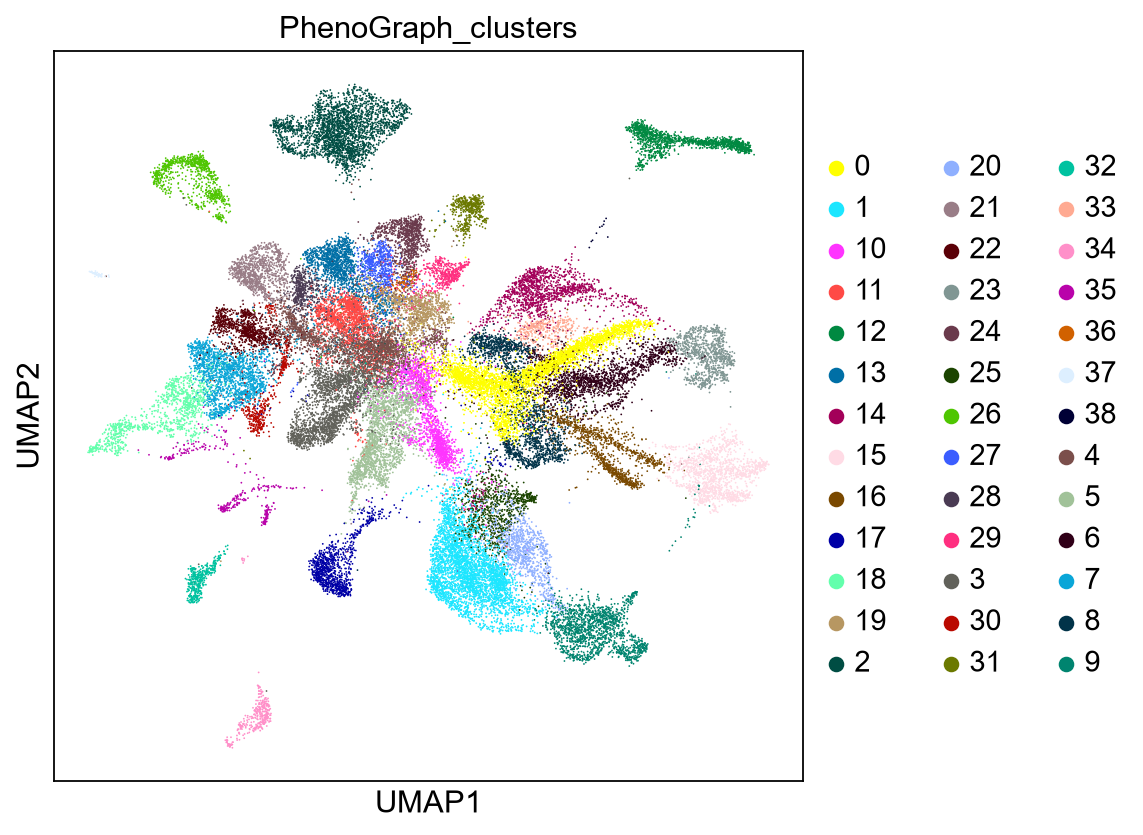

In [30]:
sc.pl.umap(
    adata,
    color="PhenoGraph_clusters"
)

In [32]:
sc.tl.rank_genes_groups(
    adata,
    groupby="PhenoGraph_clusters",
    groups=["0"],
    reference="rest",
    method="wilcoxon",
    n_genes=50,
    use_raw=False,
    key_added="markers_cluster_0"
)

MemoryError: Unable to allocate 600. MiB for an array with shape (157173279,) and data type float32